In [1]:
# compile results
import pickle

homedir = "/mnt/mirabelle/az6922_homedir/"
cm_list = ["unv1","prv1"]
nfaillinks_list_dict = dict()
nfaillinks_list_dict["leafspine_before"] = [1,3,4,6,8]
nfaillinks_list_dict["dringsu2_before"] = [1,3,4,6,8]
nfaillinks_list_dict["dringsu2_after"] = [1,3,4,6,8]
fseed_list = range(10)
scheme_list = ["dringsu2_before","leafspine_before","dringsu2_after"]
failpct_list = [0,2,4,6,8,10]
load_dict = dict()
load_dict["unv1"] = 4
load_dict["prv1"] = 4
seed = 1

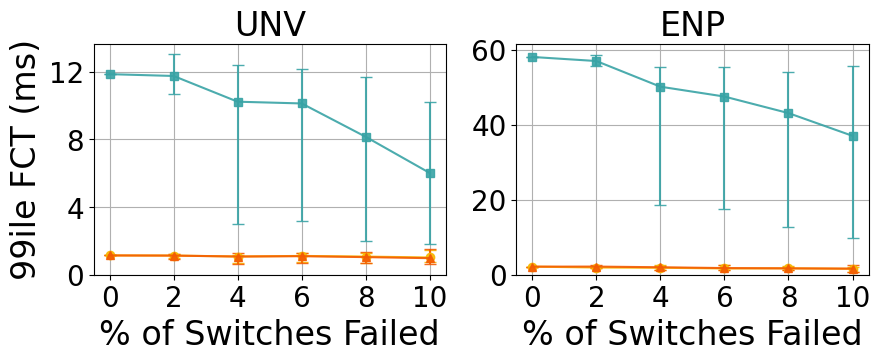

In [15]:
# plot from txt instead of pickle -- pickle files are too large
import matplotlib.pyplot as plt
import numpy as np

plottitledict = {"unv1":"UNV","prv1":"ENP","cluster_a":"DB","cluster_b":"WS","cluster_c":"HD"}
plotlabeldict = {"dringsu2_after":"Starfish (Failure-Aware)","dringsu2_before":"Starfish","leafspine_before":"Leaf-Spine"}
plotmarkers = ['o', 's', '^', 'v', 'D', 'P', '*', 'X', 'h', '1']
plotcolordict = {"dringsu2_after":"#f35b04","leafspine_before":"#38a3a5","dringsu2_before":"#f7b801"}


plotdatadict = dict()
sumfile = "fct_summary.txt"
with open(sumfile,'r') as f:
    # cluster_a/outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
    lines = f.readlines()
    for line in lines:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split('/')
        cm = outfiletokens[0]
        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotdatadict:
            plotdatadict[cm] = dict()
        plotdatadict[cm][outfile] = p99

plotevalmaindatadict = dict()
sumfile = "../eval_main/fct_summary.txt"
with open(sumfile,'r') as f:
    # cluster_a/outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
    lines = f.readlines()
    for line in lines:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split('/')
        cm = outfiletokens[0]
        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotevalmaindatadict:
            plotevalmaindatadict[cm] = dict()
        plotevalmaindatadict[cm][outfile] = p99


nr = 1
nc = len(cm_list)
fig, axs =plt.subplots(nr, nc, figsize=(nc*5, nr*3))
for ic,cm in enumerate(cm_list):
    for isc,scheme in enumerate(scheme_list):
        fct_list = list()
        load = load_dict[cm]
        fct_list_allseeds = list()
        if "dring" in scheme:
            myscheme = "dringsu2"
        else:
            myscheme = "leafspine"
        outfile = f"{cm}/outfiles/{myscheme}_load{load}_seed{seed}.out"
        p99 = plotevalmaindatadict[cm][outfile]
        fct_list_allseeds.append(p99)
        fct_list.append(fct_list_allseeds)

        for nfaillinks in nfaillinks_list_dict[scheme]:
            fct_list_allseeds = list()
            for fseed in fseed_list:
                outfile = f"{cm}/outfiles/{scheme}_nfailtor{nfaillinks}_fseed{fseed}.out"
                p99 = plotdatadict[cm][outfile]
                fct_list_allseeds.append(p99)
            fct_list.append(fct_list_allseeds)
        
        if ic==0:
            axs[ic].errorbar(failpct_list, [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker=plotmarkers[isc], label=plotlabeldict[scheme],alpha=0.9, capsize=4, color=plotcolordict[scheme])
        else:
            axs[ic].errorbar(failpct_list, [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker=plotmarkers[isc],alpha=0.9, capsize=4, color=plotcolordict[scheme])

        # print(f"{cm},{scheme}: {fct_list}")
    
    axs[ic].set_xlabel("% of Switches Failed", fontsize=24)
    axs[ic].set_title(plottitledict[cm], fontsize=24)
    axs[ic].tick_params(axis='both', labelsize=20)
    axs[ic].grid(True)
    axs[ic].set_xticks([0, 2, 4, 6, 8, 10])

axs[0].set_ylabel("99ile FCT (ms)", fontsize=24)
axs[0].set_yticks(range(0,13,4))
axs[1].set_ylim(0,None)
# fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.27), ncol=2, fontsize=22)
plt.savefig(f"eval_failure_tor.pdf", dpi=600, bbox_inches='tight')

In [11]:
unv1_dringsu2_before= [1.14018, 1.1339838, 1.0770453, 1.1120848, 1.0728182, 1.0188512]
unv1_leafspine_before= [11.8572, 11.75049, 10.228846, 10.125618, 8.152249999999999, 6.012926]
unv1_dringsu2_after= [1.14018, 1.1303893999999999, 1.0750289, 1.0957447000000002, 1.0407998, 0.9782815000000001]
prv1_dringsu2_before= [2.15518, 1.9227750000000001, 1.8586289999999999, 1.6726779999999999, 1.709577, 1.5816048000000003]
prv1_leafspine_before= [58.0804, 56.995540000000005, 50.15121, 47.51889, 43.107119999999995, 37.040154]
prv1_dringsu2_after= [2.15518, 2.170591, 1.9864680000000003, 1.773286, 1.694915, 1.6222683999999998]

In [12]:
# unv1, leafspine vs dringsu2_before:
total = 0
for i in range(6):
    total += (unv1_dringsu2_before[i]-unv1_leafspine_before[i])/unv1_leafspine_before[i]
print(total/6.0)

# prv1, leafspine vs dringsu2_before:
total = 0
for i in range(6):
    total += (prv1_dringsu2_before[i]-prv1_leafspine_before[i])/prv1_leafspine_before[i]
print(total/6.0)

# unv1, dringsu2_before vs dringsu2_after:
total = 0
for i in range(6):
    total += (unv1_dringsu2_before[i]-unv1_dringsu2_after[i])/unv1_dringsu2_after[i]
print(total/6.0)

# prv1, dringsu2_before vs dringsu2_after:
total = 0
for i in range(6):
    total += (prv1_dringsu2_before[i]-prv1_dringsu2_after[i])/prv1_dringsu2_after[i]
print(total/6.0)

-0.8818617398144443
-0.9624230510995181
0.015366903829831774
-0.04194590162989239


In [10]:
import matplotlib.pyplot as plt
import numpy as np

plottitledict = {"unv1":"UNV","prv1":"ENP","cluster_a":"DB","cluster_b":"WS","cluster_c":"HD"}
plotlabeldict = {"dringsu2_after":"Starfish (Failure-Aware)","dringsu2_before":"Starfish","leafspine_before":"Leaf-Spine"}
plotmarkers = ['o', 's', '^', 'v', 'D', 'P', '*', 'X', 'h', '1']
plotcolordict = {"dringsu2_after":"#f35b04","leafspine_before":"#38a3a5","dringsu2_before":"#f7b801"}


plotdatadict = dict()
sumfile = "fct_summary.txt"
with open(sumfile,'r') as f:
    # cluster_a/outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
    lines = f.readlines()
    for line in lines:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split('/')
        cm = outfiletokens[0]
        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotdatadict:
            plotdatadict[cm] = dict()
        plotdatadict[cm][outfile] = p99

plotevalmaindatadict = dict()
sumfile = "../eval_main/fct_summary.txt"
with open(sumfile,'r') as f:
    # cluster_a/outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
    lines = f.readlines()
    for line in lines:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split('/')
        cm = outfiletokens[0]
        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotevalmaindatadict:
            plotevalmaindatadict[cm] = dict()
        plotevalmaindatadict[cm][outfile] = p99


nr = 1
nc = len(cm_list)
# fig, axs =plt.subplots(nr, nc, figsize=(nc*5, nr*4))
for ic,cm in enumerate(cm_list):
    for isc,scheme in enumerate(scheme_list):
        fct_list = list()
        load = load_dict[cm]
        fct_list_allseeds = list()
        if "dring" in scheme:
            myscheme = "dringsu2"
        else:
            myscheme = "leafspine"
        outfile = f"{cm}/outfiles/{myscheme}_load{load}_seed{seed}.out"
        p99 = plotevalmaindatadict[cm][outfile]
        fct_list_allseeds.append(p99)
        fct_list.append(fct_list_allseeds)

        for nfailtor in nfaillinks_list_dict[scheme]:
            fct_list_allseeds = list()
            for fseed in fseed_list:
                outfile = f"{cm}/outfiles/{scheme}_nfailtor{nfailtor}_fseed{fseed}.out"
                p99 = plotdatadict[cm][outfile]
                fct_list_allseeds.append(p99)
            fct_list.append(fct_list_allseeds)

        print(f"{cm},{scheme}: {[sum(x)/len(x) for x in fct_list]}")

unv1,dringsu2_before: [1.14018, 1.1339838, 1.0770453, 1.1120848, 1.0728182, 1.0188512]
unv1,leafspine_before: [11.8572, 11.75049, 10.228846, 10.125618, 8.152249999999999, 6.012926]
unv1,dringsu2_after: [1.14018, 1.1303893999999999, 1.0750289, 1.0957447000000002, 1.0407998, 0.9782815000000001]
prv1,dringsu2_before: [2.15518, 1.9227750000000001, 1.8586289999999999, 1.6726779999999999, 1.709577, 1.5816048000000003]
prv1,leafspine_before: [58.0804, 56.995540000000005, 50.15121, 47.51889, 43.107119999999995, 37.040154]
prv1,dringsu2_after: [2.15518, 2.170591, 1.9864680000000003, 1.773286, 1.694915, 1.6222683999999998]
